### 🛠️ **Library**
*Always run this block*


In [ ]:
import os
import numpy as np
import pandas as pd

from pathlib import Path

import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpec

import ipywidgets as widgets
from IPython.display import display
from matplotlib.colors import CSS4_COLORS
from IPython.display import display, clear_output

from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import matplotlib

import cv2
import skimage as ski

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import sklearn as skl
from statistics import mode

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.stats import gaussian_kde
from scipy import ndimage

import seaborn as sns

from google.colab import drive
drive.mount('/content/gdrive')
path="/content/gdrive/MyDrive/"


Mounted at /content/gdrive


### 📂**Create the folders**
⚠️ USER INPUT REQUIRED  
*Always run this block*

In [ ]:

import os
bool_exist=False
while bool_exist==False:
 path = "/content/gdrive/MyDrive/"
 name_path = input("Enter the path where the project will be created (if the folder is in 'MyDrive' just press 'Enter'): ")
 name_project=input("Enter the name of your project: ")
 path += name_path+"/pipeline/"+ name_project+"/"
 bool_exist=os.path.isdir(path)
 if bool_exist==False:
   print("❌ The path does not exist")
 else:
  print("✅ Project :"+path)
  bool_exist=True

path_img_raw=path+"images/raw/"
path_mask_cell=path+"segmentation/segmentation_cells/mask/"
path_clust=path+"clustering/"
path_clust_mfi=path_clust+"MFI/"
path_segmentation_df=path+"segmentation/segmentation_cells/df_ROI/"

if os.path.isdir(path_img_raw)==False:
   print("❌ You have not completed the step of creating PNG images")
elif os.path.isdir(path_mask_cell)==False:
   print("❌ You have not completed the step of cells segmentation")
elif os.path.isdir(path_clust_mfi)==False:
   print("❌ You have not completed the step of calcul of MFI")
else:
 path_main_clust=path_clust+"main_clustering/"
 if os.path.isdir(path_main_clust)==False:
     os.mkdir(path_main_clust)
     print("✅ Folder for the main clustering created")
 else:
     print("✅ Folder for the main clustering already created")
 path_reduction_dimension=path_main_clust+"reduction_dimension/"
 if os.path.isdir(path_reduction_dimension)==False:
     os.mkdir(path_reduction_dimension)
     print("✅ Folder for the reduction of dimension created")
 else:
     print("✅ Folder for the reduction of dimension already created")
algo=input("Enter the algorithm used for segmentation: ")
path_mask_cell=path+"segmentation/segmentation_cells/mask_filtered/"+algo

Enter the path where the project will be created (if the folder is in 'MyDrive' just press 'Enter'): these
Enter the name of your project: Appendix
✅ Project :/content/gdrive/MyDrive/these/pipeline/Appendix/
✅ Folder for the main clustering already created
✅ Folder for the reduction of dimension already created
Enter the algorithm used for segmentation: mesmer


### ⚙️ **Select the markers used to determine the main phenotypes**
⚠️ USER INPUT REQUIRED  
*This cell allows us to select the markers useful for determining the main finotypes that will later be used to define the subpopulations*

##### 🛠️ Functions

In [ ]:
def choose_markers_checkboxes(list_marker):
    print("Select the markers you need to define the main phenotypes: ")
    checkboxes = [
        widgets.Checkbox(value=False, description=marker)
        for marker in list_marker
    ]

    validate = widgets.Button(description="✅ Confirm selection")

    selected_markers = []

    def on_validate(b):
        selected_markers.clear()
        selected_markers.extend(
            [cb.description for cb in checkboxes if cb.value]
        )
        print("✔ Selected markers:", selected_markers)

    validate.on_click(on_validate)

    display(widgets.VBox(checkboxes))
    display(validate)

    return selected_markers


##### ⚙️ Execution
⚠️ USER INPUT REQUIRED


**Choose the markers used to define the main phenotypes**

In [ ]:
df_mfi_tot=pd.read_csv(path_clust+"mfi_corrected_arcsinh_std.csv")
df_mfi_tot.drop(["Cell_ID","area","centroid-0","centroid-1","ROI","label"],axis=1,inplace=True)
list_marker=df_mfi_tot.columns.to_list()
available_markers = list_marker
selected_markers = choose_markers_checkboxes(available_markers)


Select the markers you need to define the main phenotypes: 


Button(description='✅ Confirm selection', style=ButtonStyle())

In [ ]:
df_mfi_tot=pd.read_csv(path_clust+"mfi_corrected_arcsinh_std.csv")
df_mfi_select=df_mfi_tot[selected_markers].copy()
df_mfi_select.loc[:,"Cell_ID"]=df_mfi_tot.loc[:,"Cell_ID"]
df_mfi_select.loc[:,"area"]=df_mfi_tot.loc[:,"area"]
df_mfi_select.loc[:,"centroid-0"]=df_mfi_tot.loc[:,"centroid-0"]
df_mfi_select["centroid-1"]=df_mfi_tot["centroid-1"]
df_mfi_select["ROI"]=df_mfi_tot["ROI"]
#df_mfi_select["coord"]=df_mfi_tot["coord"]
df_mfi_select["label"]=df_mfi_tot["label"]
print(df_mfi_select.shape)
print(df_mfi_select.columns)
df_mfi_select.to_csv(path_main_clust+"mfi_select.csv",index=False)
print(f"✅ The files containing the DataFrames with the MFI for the clustering of the main phenotypes can be found in the following folder:  {path_clust} mfi_select.csv")
df_mfi_select.head()

(230080, 6)
Index(['Cell_ID', 'area', 'centroid-0', 'centroid-1', 'ROI', 'label'], dtype='object')
✅ The files containing the DataFrames with the MFI for the clustering of the main phenotypes can be found in the following folder:  /content/gdrive/MyDrive/these/pipeline/Appendix/clustering/ mfi_select.csv


,Cell_ID,area,centroid-0,centroid-1,ROI,label
0,0,159.0,33.534591,741.943396,ROI,2
1,1,248.0,35.709677,643.830645,ROI,5
2,2,342.0,34.716374,987.476608,ROI,6
3,3,135.0,35.918519,153.370370,ROI,7
4,4,208.0,36.475962,269.913462,ROI,8


### 📊 **Plot the MFI**

In [ ]:
df_num=df_mfi_select.drop(["Cell_ID","area","centroid-0","centroid-1","ROI","label"],axis=1)

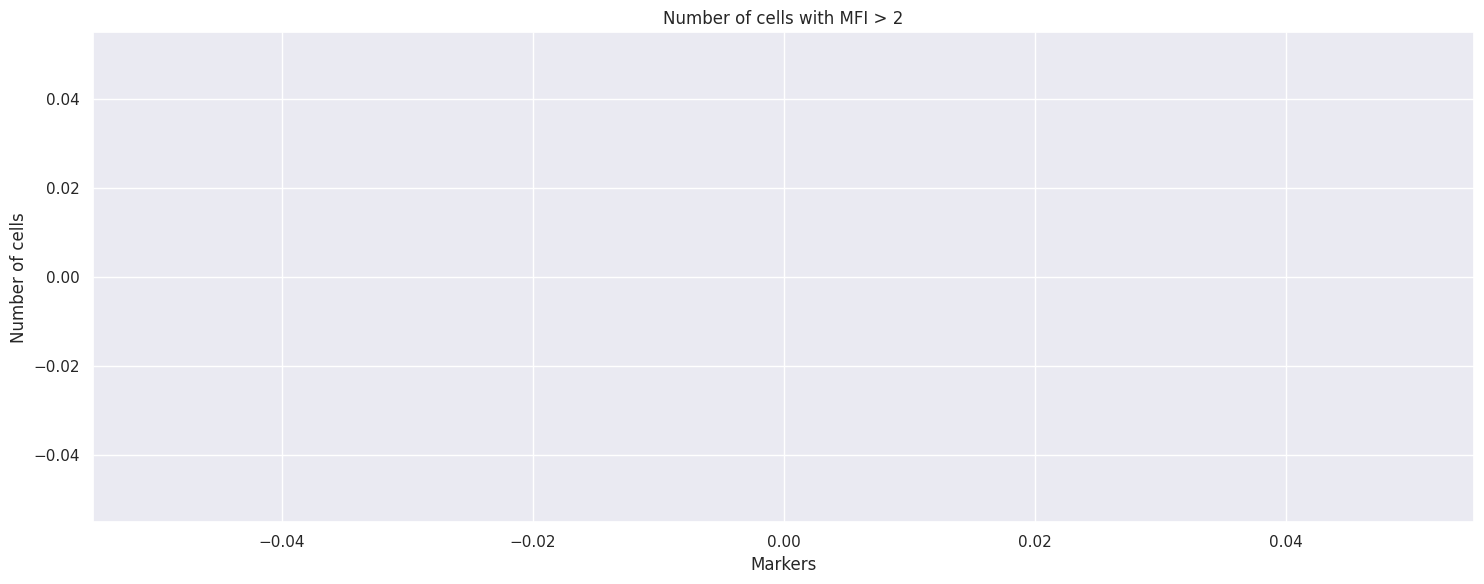

Saved bar chart to: /content/gdrive/MyDrive/these/pipeline/Appendix/clustering/main_clustering/Histogram_main_markers.png


In [ ]:

# --- Configurable threshold and output path ---
THRESH = 2
out_dir = Path(path_main_clust)
out_dir.mkdir(parents=True, exist_ok=True)
out_png = out_dir / "Histogram_main_markers.png"

# Ensure numeric input (coerce non-numeric to NaN, then compare)
#df_num = df_mfi_select.apply(pd.to_numeric, errors="coerce")

# Per-marker counts of cells above threshold (ignores NaN automatically)
counts = (df_num > THRESH).sum().astype(int)

# Sort descending for readability
counts_sorted = counts.sort_values(ascending=False)

# Colors (rainbow); feel free to swap for a colorblind-friendly colormap if needed
colors = plt.cm.rainbow(np.linspace(0, 1, len(counts_sorted)))

# Plot
plt.figure(figsize=(15, 6))
ax = plt.gca()
bars = ax.bar(counts_sorted.index, counts_sorted.values, color=colors)

ax.set_title(f"Number of cells with MFI > {THRESH}")
ax.set_xlabel("Markers")
ax.set_ylabel("Number of cells")

# If there are many markers, angle labels for readability
if len(counts_sorted) > 20:
    plt.xticks(rotation=45, ha="right")
else:
    plt.xticks(rotation=0)

# Add value labels on bars (use bar_label if available)
try:
    ax.bar_label(bars, labels=[str(v) for v in counts_sorted.values], padding=2)
except Exception:
    # Fallback manual text placement (older Matplotlib)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, h, f"{int(h)}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved bar chart to: {out_png}")


RecursionError: maximum recursion depth exceeded

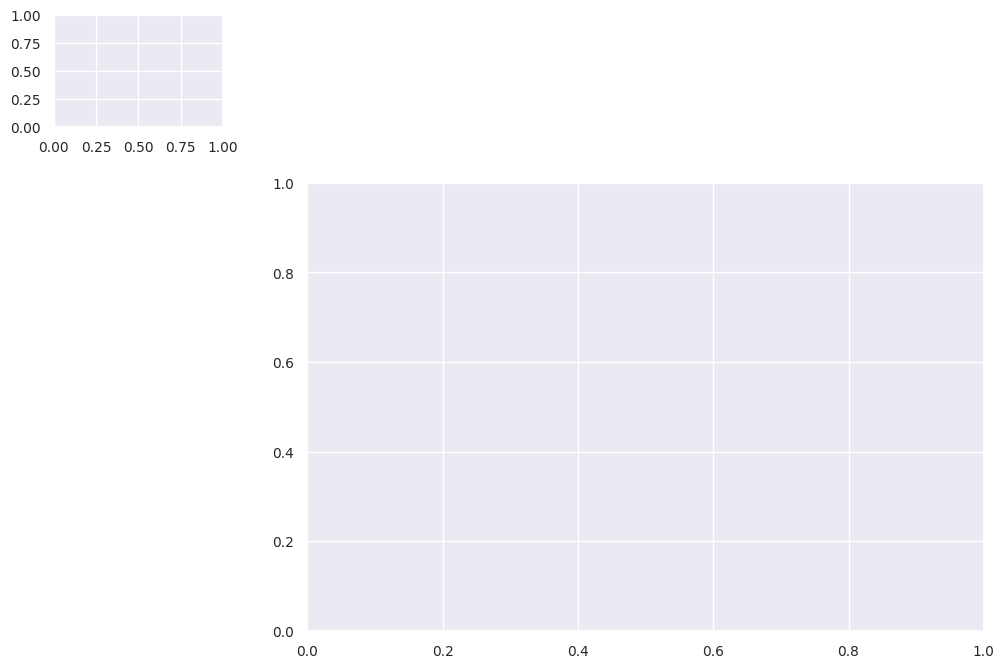

In [ ]:
# --- Sampling (fixed seed for reproducibility) ---
df_sample = df_num.sample(n=15000, random_state=42)

# Optional: z-score per marker to balance scales (comment out if already standardized)
# df_sample = (df_sample - df_sample.mean()) / df_sample.std(ddof=0)

# --- Aesthetic defaults ---
sns.set_theme(context="notebook", style="white")
sns.set(font_scale=0.9)

# --- Build a clustered heatmap ---
# You can tweak method/metric as needed (e.g., method="average", metric="euclidean")
cg = sns.clustermap(
    data=df_sample,
    cmap="YlGnBu",
    vmin=-5, vmax=5,                 # keep your original range; adjust if you z-score
    xticklabels=True, yticklabels=False,
    linewidths=0,                    # cleaner tiles
    col_cluster=True, row_cluster=True,
    method="average", metric="euclidean",
    figsize=(12, 8),
    cbar_kws={"label": "MFI (scaled)"}
)

# --- Title + layout polish ---
cg.fig.suptitle("Heatmap of Cells MFI × Markers", fontsize=14, y=1.02)
cg.ax_heatmap.set_xlabel("Markers")
cg.ax_heatmap.set_ylabel("Cells")

# Rotate x tick labels for readability
plt.setp(cg.ax_heatmap.get_xticklabels(), rotation=45, ha="right")

# Light frame & clean spines
for spine in cg.ax_heatmap.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)

# --- Save nicely ---
out_dir = Path(path_main_clust)
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "heatmap_cells.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved heatmap to: {out_path}")


### 📊 **Coexpression of the markers in the whole dataset**
⚠️ USER INPUT REQUIRED   
*Graph showing the pairwise co-expression of each marker for all cells*

#### 🛠️ Functions

In [ ]:
def plot_density_df(df, marker_x, marker_y, path_out,
                    palette='tab10',
                    x_thresh=None, y_thresh=None,
                    ):
    """
    Trace la densité 2D d'un couple de marqueurs et ajoute :
      - Lignes seuils rouges (x_thresh, y_thresh)
      - Un résumé des comptes et pourcentages :
        X+, Y+, double+, double-
    """

    plt.figure(figsize=(8, 6))
    x = df[marker_x].values
    y = df[marker_y].values

    # Calcul de la densité locale
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)

    # Trier les points (les plus denses au-dessus)
    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]

    # Scatter coloré selon densité
    sc = plt.scatter(x, y, c=z, cmap='viridis', s=3, edgecolor='none', alpha=0.7)

    # Densité 2D contours
    sns.kdeplot(x=x, y=y, levels=5, linewidths=1, color='black', alpha=0.6)

    # Ajouter lignes seuils si données
    if x_thresh is not None:
        plt.axvline(x=x_thresh, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    if y_thresh is not None:
        plt.axhline(y=y_thresh, color='red', linestyle='--', linewidth=1.5, alpha=0.8)

    # Calcul des populations selon les seuils
    if x_thresh is not None and y_thresh is not None:
        x_pos = x > x_thresh
        y_pos = y > y_thresh

        n_total = len(x)
        n_xpos = np.sum(x_pos)
        n_ypos = np.sum(y_pos)
        n_double_pos = np.sum(x_pos & y_pos)
        n_double_neg = np.sum(~x_pos & ~y_pos)

        # Calcul des pourcentages
        p_xpos = 100 * n_xpos / n_total
        p_ypos = 100 * n_ypos / n_total
        p_double_pos = 100 * n_double_pos / n_total
        p_double_neg = 100 * n_double_neg / n_total

        # Texte à afficher
        txt = (
            f"Total cells: {n_total}\n"
            f"{marker_x}+ : {n_xpos} ({p_xpos:.1f}%)\n"
            f"{marker_y}+ : {n_ypos} ({p_ypos:.1f}%)\n"
            f"Double + : {n_double_pos} ({p_double_pos:.1f}%)\n"
            f"Double - : {n_double_neg} ({p_double_neg:.1f}%)"
        )

        # Afficher dans le coin supérieur droit
        plt.text(0.98, 0.98, txt, transform=plt.gca().transAxes,
                 fontsize=9, color='white', fontweight='bold',
                 ha='right', va='top',
                 bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.4'))

    # Légendes et titre
    plt.xlabel(marker_x)
    plt.ylabel(marker_y)
    plt.title(f"{marker_x} vs {marker_y}")
    plt.colorbar(sc, label='Density')

    plt.tight_layout()
    plt.savefig(path_out + f"/{marker_x}_{marker_y}.png", dpi=300)
    plt.show()


#### ⚙️ Execution

In [ ]:
path_coexpression=path_main_clust+"coexpression_markers_all_cells/"
if os.path.isdir(path_coexpression)==False:
  os.mkdir(path_coexpression)

In [ ]:
df_mfi_pos=pd.read_csv(path_main_clust+"mfi_select.csv")
df_mfi_pos=df_mfi_pos.drop(["Cell_ID","area","centroid-0","centroid-1","ROI","label"],axis=1)

In [ ]:
threshold=float(input("Enter the minimum threshold to select the markers: "))
sample=int(input("Enter the number of cells to sample: "))
threshold=float(threshold)

In [ ]:
# Requirements:
# pip install tqdm


from itertools import combinations
from tqdm.auto import tqdm

# List of markers to pairwise plot
df_sample=df_mfi_pos.sample(n=sample, random_state=42)
list_marker = df_sample.columns.to_list()

# Total number of unique pairs (n choose 2) for progress tracking
total_pairs = len(list_marker) * (len(list_marker) - 1) // 2

# Iterate over all unique marker pairs with a progress bar
for marker1, marker2 in tqdm(
    combinations(list_marker, 2),
    total=total_pairs,
    desc="Plotting density for marker pairs",
    unit="pair"
):
    # Call your plotting function for each pair
    # Expected signature: plot_density_df(df, x_marker, y_marker)
    plot_density_df(df_sample, marker1, marker2,path_coexpression,x_thresh=threshold,y_thresh=threshold)
print(f"✅ The files can be found in the following folder:  {path_coexpression}")


### ⚙️ **Reduction of dimension before clustering**
⚠️ USER INPUT REQUIRED  
*To aid in cell clustering, dimensionality reduction is performed beforehand using PCA on the MFIs.*


In [ ]:
df_mfi_pos=pd.read_csv(path_main_clust+"mfi_select.csv")
exclude_column=["Cell_ID","area","centroid-0","centroid-1","ROI","label"]
df_mfi_pos.drop(exclude_column, axis=1, inplace=True)
print(df_mfi_pos.columns)
pca = PCA().fit(df_mfi_pos)
explained_var = np.cumsum(pca.explained_variance_ratio_)

plt.plot(explained_var)
plt.xlabel("Number of components")
plt.ylabel("Cumulated Variance")
plt.grid()
plt.show()

In [ ]:
nb_var=input("Enter the number of components to use: ")
nb_var=int(nb_var)

pca = PCA(n_components=nb_var)
X_pca = pca.fit_transform(df_mfi_pos)

df_pacmap=pd.DataFrame(X_pca)
df_pacmap.to_csv(path_main_clust+"pca_reduction_all.csv",index=False)
print(df_pacmap.shape)
df_pacmap.head()
print(f"✅ The files containing the DataFrames with this reduction of dimension:  {path_main_clust}pca_reduction_all.csv")

### ⚙️ **Training of Phenographe**
*Clustering of cells according to the MFI of markers selected by the Phenograph algorithm to determine the main phenotypes*



#### 🛠️ Functions

In [ ]:
%pip install PhenoGraph
import phenograph

#### ⚙️ Execution

In [ ]:
df_pca=pd.read_csv(path_main_clust+"pca_reduction_all.csv")
df_mfi_pos=pd.read_csv(path_main_clust+"mfi_select.csv")
communities, graph, Q = phenograph.cluster(df_pca)
print("Number of clusters: "+str(len(np.unique(communities))))
df_mfi_pos["cluster"]=communities
df_mfi_pos.to_csv(path_main_clust+"/mfi_corrected_cluster.csv",index=False)
print(f"✅ This dataframe with the clusters can be found in the following folder:  {path_main_clust}mfi_corrected_cluster.csv")

### 📊 **Cluster-wise Heatmap of Mean Marker Expression (MFI)**
*Heatmap showing the expression of the selected markers within each cluster*

#### 🛠️ **Functions**

In [ ]:
def heatmap_histo(df, name_value, title, path, threshold, vmin, vmax):
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle
    from matplotlib.gridspec import GridSpec
    from scipy.cluster.hierarchy import linkage, leaves_list

    sns.set(font_scale=1)

    # --- Data ---
    data = df.groupby(name_value).mean()
    counts = df[name_value].value_counts().sort_index()

    linkage_result = linkage(data, method="ward")
    order = leaves_list(linkage_result)
    data = data.iloc[order]
    counts = counts.iloc[order]

    n_clusters = len(data)
    fig = plt.figure(figsize=(10, max(6, n_clusters * 0.4)))
    fig.patch.set_facecolor('white')
    gs = GridSpec(nrows=1, ncols=2, width_ratios=[1.2, 5], wspace=0.02)

    # --- Histogram ---
    ax_bar = fig.add_subplot(gs[0])
    y_positions = [i + 0.5 for i in range(n_clusters)]

    bars = ax_bar.barh(
        y=y_positions,
        width=counts.values,
        height=1,
        color='gray'
    )

    # Add cell counts inside the histogram
    for y, count in zip(y_positions, counts.values):
        ax_bar.text(
            count - 1,
            y,
            str(count),
            va='center',
            ha='right',
            fontsize=8
        )

    ax_bar.set_yticks([])
    ax_bar.invert_xaxis()
    ax_bar.set_xlabel("")
    ax_bar.set_xticks([])
    ax_bar.xaxis.set_label_position('top')
    ax_bar.set_facecolor('none')
    ax_bar.yaxis.set_ticks_position('none')

    for spine in ['top', 'right', 'bottom']:
        ax_bar.spines[spine].set_visible(False)

    # --- Heatmap (without colorbar) ---
    ax_heatmap = fig.add_subplot(gs[1])
    heatmap = sns.heatmap(
        data,
        ax=ax_heatmap,
        vmin=vmin,
        vmax=vmax,
        cmap="vlag",
        linewidths=0.5,
        linecolor='gray',
        xticklabels=True,
        yticklabels=False,
        cbar=False   # cbar created separately
    )

    # Y-axis ticks on the right side
    ax_heatmap.set_yticks([i + 0.5 for i in range(n_clusters)])
    ax_heatmap.set_yticklabels(data.index, fontsize=12)
    ax_heatmap.yaxis.tick_right()
    ax_heatmap.yaxis.set_label_position("right")

    # Align histogram and heatmap vertically
    ax_bar.set_ylim(ax_heatmap.get_ylim())

    # --- Red box highlighting values above threshold ---
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            value = data.iloc[i, j]
            if value > threshold:
                rect = Rectangle((j, i), 1, 1, linewidth=2,
                                 edgecolor='red', facecolor='none')
                ax_heatmap.add_patch(rect)

    # --- Main title ---
    fig.suptitle(title, fontsize=16, y=1.05)

    # --- Colorbar placed above the heatmap ---
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    import matplotlib.cm as cm

    norm = plt.Normalize(vmin=data.values.min(), vmax=data.values.max())
    sm = plt.cm.ScalarMappable(cmap="vlag", norm=norm)
    sm.set_array([])

    # Custom position: [left, bottom, width, height]
    cax = fig.add_axes([0.13, 0.94, 0.3, 0.015])
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
    cbar.ax.tick_params(labelsize=8)

    # --- Save ---
    plt.tight_layout(rect=[0, 0, 1, 0.93])  # leave space for title and colorbar
    plt.savefig(path + f"Heatmap_{name_value}.png", bbox_inches='tight')
    plt.show()


#### ⚙️ **Execution**

In [ ]:
df_mfi=pd.read_csv(path_main_clust+"/mfi_corrected_cluster.csv")
df_mfi=df_mfi.drop(["Cell_ID","area","centroid-0","centroid-1","ROI","label"],axis=1)
print(df_mfi.shape)
df_mfi.head()

In [ ]:
heatmap_histo(df_mfi,"cluster","Expression of markers according to the clusters",path_main_clust,threshold=1.5,vmin=0,vmax=3)
print(f"✅ The heatmap can be found there:  {path_main_clust}")


### 📊 **Reduction of dimension of clusters**
*To ensure the homogeneity of the clusters, dimensionality reduction is performed to visualize their spatial distribution.*

#### 🛠️ Functions

In [ ]:
%pip install pacmap
import pacmap


In [ ]:
def display_reduction_cluster(cluster,reduced_vector,lbl,size_picture,path,title,subtitle):
  list_colors=[]
  for i in range(reduced_vector.shape[0]):
    if lbl[i]==cluster:
     list_colors.append("red")
    else:
     list_colors.append("aquamarine")

  plt.figure(figsize=size_picture)
  plt.title(title,fontsize=40)
  plt.scatter(reduced_vector[:,0],reduced_vector[:,1],c=list_colors,s=1,label=cluster)
  plt.legend()
  plt.axis('off')
  plt.savefig(path+title+"_"+str(subtitle)+".png")
  plt.show()

In [ ]:
def display_reduction_roi(reduced_vector,lbl,size_picture,path,title,subtitle):

  rgb_colors = {}
  for name, hex in matplotlib.colors.cnames.items():
    rgb_colors[name] = matplotlib.colors.to_rgb(hex)
  list_col=["red","blue","green","purple","yellow","aquamarine","brown","chartreuse","cornflowerblue","coral","darkolivegreen","darkorange","darkslateblue","deeppink","gold","greenyellow","crimson","indigo","fuchsia","lightsalmon","lightgray","maroon"]
  list_col2=["aquamarine","blue","blueviolet","brown","orange","red","cornflowerblue","coral","darkolivegreen","darkgoldenrod","darkslateblue","deeppink","gold","greenyellow","indigo","fuchsia","lightsalmon","lightgray","maroon"]
  list_col2=list(rgb_colors.keys())[5:]
  dico_pheno_num={}
  for i,v in enumerate(np.unique(lbl)):
    dico_pheno_num[v]=i

  list_colors=[]
  for i in range(reduced_vector.shape[0]):
    if lbl[i]=="None":
      list_colors.append("white")
    else:
      list_colors.append(list_col2[dico_pheno_num[lbl[i]]])

  fig = plt.figure(layout='constrained', figsize=size_picture)
  fig.suptitle(title,fontsize=40)
  subfigs = fig.subfigures(2,1,height_ratios=(5,1))
  ax=subfigs[0].subplots()
  ax.scatter(reduced_vector[:,0],reduced_vector[:,1],c=list_colors,s=1)
  ax.axis('off')

  list_clust=list(np.unique(lbl))
  if "None" in list_clust:
   list_clust.remove("None")
  axs=subfigs[1].subplots(1,len(list_clust))
  for n,ax2 in enumerate(axs):
    img=np.zeros((30,30,3))
    img[:,:]=rgb_colors[list_col2[dico_pheno_num[list_clust[n]]]]
    ax2.imshow(img)
    ax2.set_title(str(list_clust[n]))
    ax2.title.set_size(15)
    ax2.axis('off')
  subfigs[1].suptitle(subtitle,fontsize=20)
  fig.savefig(path+title+"_"+subtitle+".png")
  plt.show()

In [ ]:

def plot_pacmap(df_pacmap,feature, figsize=(8, 6), savepath=None,title=""):
    # Order phenotypes by frequency (optional but nice for legend)
    pheno_counts = df_pacmap[feature].value_counts()
    phenotypes = pheno_counts.index.tolist()

    # Palette with as many distinct colors as phenotypes
    palette = sns.color_palette("tab20", n_colors=len(phenotypes))
    pheno_to_color = {ph: palette[i] for i, ph in enumerate(phenotypes)}

    plt.figure(figsize=figsize)
    ax = plt.gca()

    # Plot phenotype by phenotype (gives more control than seaborn.scatterplot)
    for ph in phenotypes:
        sub = df_pacmap[df_pacmap[feature] == ph]
        ax.scatter(
            sub['0'],
            sub['1'],
            s=8,
            color=pheno_to_color[ph],
            alpha=0.7,
            edgecolor="none",
            label=f"{ph} (n={len(sub)})"
        )

    ax.set_xlabel("PaCMAP 1", fontsize=11)
    ax.set_ylabel("PaCMAP 2", fontsize=11)
    ax.set_title(title, fontsize=13, pad=10)

    # Legend outside the plot
    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0.0,
        fontsize=9,
        markerscale=4.0,
        title=feature
    )

    # Remove top/right spines for a cleaner look
    sns.despine(ax=ax)

    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
        print(f"✅ The graph can be found there:  {savepath}")

    plt.show()




#### ⚙️ Execution

In [ ]:
path_reduction_dimension_clust=path_reduction_dimension+"reduction_dimension_cluster/"
if os.path.isdir(path_reduction_dimension_clust)==False:
  os.mkdir(path_reduction_dimension_clust)

In [ ]:
df_mfi=pd.read_csv(path_main_clust+"mfi_corrected_cluster.csv")
labels_km=df_mfi["cluster"]
df_pacmap=df_mfi.drop(["Cell_ID","area","centroid-0","centroid-1","ROI","label","cluster"],axis=1)
print(df_mfi.shape)
print(df_mfi.columns)
embedding = pacmap.PaCMAP(n_components=2, n_neighbors=None, MN_ratio=0.5, FP_ratio=2.0)
X_transformed = embedding.fit_transform(df_pacmap, init="pca")
X_transformed.shape

In [ ]:
df_pacmap=pd.DataFrame(X_transformed,columns=["0","1"])
df_pacmap.to_csv(path_main_clust+"pacmap_reduction_all.csv")
print(df_pacmap.shape)
df_pacmap.head()

In [ ]:
df_pacmap["cluster"]=df_mfi["cluster"]
plot_pacmap(df_pacmap,"cluster", savepath=path_reduction_dimension+"Pacmap_clusters",title="Clusters displayed on the Pacmap reduction")


In [ ]:
path_reduction_dimension_cluster=path_reduction_dimension+"reduction_dimension_cluster/"
if os.path.isdir(path_reduction_dimension_cluster)==False:
  os.mkdir(path_reduction_dimension_cluster)

In [ ]:

labels_km = list(df_pacmap["cluster"])

for cluster in df_pacmap["cluster"].unique():
    # Work on a copy
    df = df_pacmap.copy()

    # Create a new column used for coloring:
    # current cluster = its ID, others = "other"
    df["cluster_display"] = np.where(
        df["cluster"] == cluster,
        str(cluster),
        "other"
    )

    savepath = os.path.join(
        path_reduction_dimension_cluster,
        f"cluster_{cluster}.png"
    )

    plot_pacmap(
        df,
        "cluster_display",
        savepath=savepath,
        title=f"Cluster {cluster} displayed on the PaCMAP reduction"
    )



### 📊 **Representation of clusters on the biopsy**
⚠️ USER INPUT REQUIRED  
*To verify the spatial distribution of clusters on the biopsy and their consistency with markers, this cell creates images masking the cells belonging to each cluster and comparing them to the original marker.*

#### 🛠️ Functions

In [ ]:
def draw_outline(img, list_pixel, color=[255, 255, 0], width=1):
    # Convertir en RGB si image grayscale
    if len(img.shape) == 2:
        img = np.stack([img]*3, axis=-1)

    # Créer un masque binaire à partir de list_pixel
    mask = np.zeros(img.shape[:2], dtype=np.uint8)
    for pixel in list_pixel:
        x, y = map(int, pixel.split(","))
        if 0 <= x < mask.shape[0] and 0 <= y < mask.shape[1]:
            mask[x, y] = 255

    # Trouver les contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Dessiner les contours sur l'image
    img = cv2.drawContours(img, contours, -1, color, thickness=width)

    return img


#### ⚙️ Execution

In [ ]:
processing=input("Enter 1 or 2 to choose the image processing used to display the clusters: ")

In [ ]:
path_representation=path_main_clust+"representation_cluster_roi/"
if os.path.isdir(path_representation)==False:
  os.mkdir(path_representation)
path_img=path+"images/img_processing_"+processing+"/Marker/"

In [ ]:
df_mfi=pd.read_csv(path_main_clust+"mfi_corrected_cluster.csv")
print(df_mfi.shape)
df_mfi.head()

In [ ]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from skimage.segmentation import find_boundaries
from tqdm.auto import tqdm

# ======================================================
# Préparation clusters / marqueurs dominants
# ======================================================

df_cluster = df_mfi.drop(
    columns=["Cell_ID", "area", "centroid-0", "centroid-1", "ROI","label"],
    errors="ignore"
)

df_cluster = df_cluster.groupby("cluster").mean()

df_max = df_cluster.idxmax(axis=1)

# enlever le premier max pour trouver le second
for cl in df_cluster.index:
    df_cluster.loc[cl, df_max.loc[cl]] = 0

df_max2 = df_cluster.idxmax(axis=1)

list_roi = df_mfi["ROI"].unique()

# ======================================================
# Fonctions utilitaires
# ======================================================

def read_gray(path):
    arr = np.array(Image.open(path))
    if arr.ndim > 2:
        arr = arr[..., 0]
    return arr.astype(np.float32)


def normalize_robust(arr, p_low=1, p_high=99.8):
    lo, hi = np.percentile(arr, [p_low, p_high])
    if hi <= lo:
        return np.zeros_like(arr, dtype=np.uint8)
    arr = np.clip(arr, lo, hi)
    arr = (arr - lo) / (hi - lo)
    return (arr * 255).astype(np.uint8)


def get_mask(path_mask_cell, roi):
    for ext in (".tif", ".tiff", ".png"):
        p = os.path.join(path_mask_cell, roi + ext)
        if os.path.isfile(p):
            return np.array(Image.open(p))
    return None


# ======================================================
# Boucle principale ROI × cluster
# ======================================================

for roi in tqdm(list_roi, desc="ROIs"):

    mask = get_mask(path_mask_cell, roi)
    if mask is None:
        continue

    if mask.ndim > 2:
        mask = mask[..., 0]

    mask = mask.astype(np.int32)

    for cluster in df_cluster.index:

        marker_max = df_max.loc[cluster]
        marker_max2 = df_max2.loc[cluster]

        out_dir = os.path.join(path_representation, str(cluster))
        os.makedirs(out_dir, exist_ok=True)

        # ======================
        # Chargement marqueurs
        # ======================

        img1 = read_gray(os.path.join(path_img, marker_max, roi + ".png"))
        img2 = read_gray(os.path.join(path_img, marker_max2, roi + ".png"))

        img1 = normalize_robust(np.arcsinh(img1 * 3))
        img2 = normalize_robust(np.arcsinh(img2 * 3))

        img_rgb = np.zeros((*img1.shape, 3), dtype=np.uint8)
        img_rgb[..., 0] = img1
        img_rgb[..., 1] = img2

        # ======================
        # Sélection labels du cluster
        # ======================

        labels_cluster = df_mfi.loc[
            (df_mfi["ROI"] == roi) & (df_mfi["cluster"] == cluster),
            "label"
        ].astype(int).unique()

        if len(labels_cluster) == 0:
            continue

        # ======================
        # Contours COMPLETS
        # ======================

        mask_sel = np.where(np.isin(mask, labels_cluster), mask, 0)
        boundaries = find_boundaries(mask_sel, mode="outer")

        # épaissir contours
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        boundaries = cv2.dilate(boundaries.astype(np.uint8), kernel) > 0

        # ======================
        # Dessin
        # ======================

        img_rgb[boundaries] = [255, 255, 255]

        # image binaire cluster (QC)
        img_cluster = (mask_sel > 0).astype(np.uint8) * 255

        # ======================
        # Figure
        # ======================

        plt.figure(figsize=(16, 8))

        plt.subplot(1, 4, 1)
        plt.title(f"Cluster {cluster}")
        plt.imshow(img_cluster, cmap="gray")
        plt.axis("off")

        plt.subplot(1, 4, 2)
        plt.title(f"Red: {marker_max} | Green: {marker_max2}")
        plt.imshow(img_rgb)
        plt.axis("off")

        plt.subplot(1, 4, 3)
        plt.title(marker_max)
        plt.imshow(img1, cmap="gray")
        plt.axis("off")

        plt.subplot(1, 4, 4)
        plt.title(marker_max2)
        plt.imshow(img2, cmap="gray")
        plt.axis("off")

        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, roi + ".png"),
                    dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close()


### 📊 **Histogramme overlay of MFI**
*Graph comparing the distribution of Mfi within the different clusters*

#### 🛠️ Functions

In [ ]:
def plot_mfi_histogram_by_cluster(df, marker, cluster_col='cluster', bins=None, offset=0.1, colors=None):

    clusters = df[cluster_col].unique()
    clusters.sort()

    if colors is None:
        colors = plt.cm.tab10.colors

    # Préparation des données
    data_by_cluster = {
        f'Cluster {c}': df[df[cluster_col] == c][marker].dropna().values
        for c in clusters
    }

    # Calcul des bins
    all_values = np.concatenate(list(data_by_cluster.values()))
    if bins is None:
        bins = np.linspace(np.min(all_values), np.max(all_values), 100)

    plt.figure(figsize=(40, 30))

    for i, (label, data) in enumerate(data_by_cluster.items()):
        hist, bin_edges = np.histogram(data, bins=bins, density=True)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        color = colors[i % len(colors)]

        plt.plot(bin_centers, hist + i * offset, color=color, linewidth=2, label=label)
        plt.fill_between(bin_centers, i * offset, hist + i * offset, color=color, alpha=0.3)

    plt.xlabel(marker,fontsize=30)
    plt.ylabel('Density + offset',fontsize=30)
    plt.title(f'Distribution of {marker} by Cluster',fontsize=40)
    plt.xlim(-2,10)
    #plt.legend()
    plt.xticks(fontsize=30)
    plt.yticks(fontsize=30)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(path_histo_overlay+marker+".png")
    plt.show()


#### ⚙️ Execution

In [ ]:
path_histo_overlay=path_main_clust+"histograme_overlay/"
if os.path.isdir(path_histo_overlay)==False:
  os.mkdir(path_histo_overlay)

In [ ]:
df_mfi=pd.read_csv(path_main_clust+"/mfi_corrected_cluster.csv")
df_mfi=df_mfi.drop(["Cell_ID","area","centroid-0","centroid-1","ROI","coord"],axis=1)

In [ ]:
for marker in df_mfi.columns[:-1]:
  plot_mfi_histogram_by_cluster(df_mfi, marker,offset=1)
print(f"✅ The files are available here:  {path_histo_overlay}")


### 📊 **Graphs showing the presence of markers within clusters and vice versa**
*Graph showing the distribution of the MFI of different markers within a cluster*

#### 🛠️ Functions

In [ ]:
def plot_mfi_cluster(df_mfi,path_file):

  list_cluster=sorted(df_mfi["cluster"].unique())
  for cluster in list_cluster:
     print("Cluster: "+str(cluster))
     list_data=[]
     nb_cell=len(df_mfi.loc[df_mfi.loc[:,"cluster"]==cluster])
     nb_tot=df_mfi.shape[0]
     list_marker=df_mfi.columns[:-1]
     list_col=[]
     for m in list_marker:
       list_m=list(df_mfi.loc[df_mfi.loc[:,"cluster"]==cluster][m])
       list_data.append(list_m)
     for i in range(len(list_data)):
       if np.mean(list_data[i])>1.5:
        list_col.append("red")
       else:
        list_col.append("blue")
     pos=[float(p) for p in range(0,len(list_data))]
     fig,ax = plt.subplots(1,1,figsize=(60,10))
     violin=ax.violinplot(list_data,pos,showextrema=False,showmedians=True)
     c=0
     for pc in violin['bodies']:
       pc.set_facecolor(list_col[c])
       c+=1
     ax.set_title("Cluster: "+str(cluster)+" ( Nb of cells "+str(nb_cell)+" / "+str(nb_tot)+" )",fontsize=40)
     ax.set_xticks(np.arange(0,len(list_marker)),list_marker,size=25)
     ax.tick_params(axis='y', labelsize=20)
     plt.ylabel("Z-score",size=30)
     plt.savefig(path_file+str(cluster)+".png")


In [ ]:
def plot_mfi_marker(df_mfi,path_file):

  list_marker=list(df_mfi.columns[:-1])
  for marker in list_marker:
     print("marker: "+str(marker))
     list_data=[]
     list_cluster=sorted(df_mfi["cluster"].unique())
     for c in list_cluster:
       list_c=list(df_mfi.loc[df_mfi.loc[:,"cluster"]==c][marker])
       list_data.append(list_c)
     list_col=[]
     for i in range(len(list_data)):
        if np.mean(list_data[i])>1.5:
          list_col.append("red")
        else:
          list_col.append("blue")
     pos=[float(p) for p in range(0,len(list_data))]
     fig,ax = plt.subplots(1,1,figsize=(90,10))
     violin=plt.violinplot(list_data,pos,showextrema=False,showmedians=True)
     c=0
     for pc in violin['bodies']:
       pc.set_facecolor(list_col[c])
       c+=1
     ax.set_title("Marqueur: "+marker,fontsize=40)
     plt.ylabel("Z-score",size=30)
     ax.set_xticks(np.arange(0,len(list_cluster)),list_cluster,size=25)
     plt.savefig(path_file+str(marker)+".png")


#### ⚙️ Execution

In [ ]:
path_plot_clust=path_main_clust+"plot_mfi_cluster/"
path_plot_marker=path_main_clust+"plot_mfi_marker/"

In [ ]:
if os.path.isdir(path_plot_clust)==False:
  os.mkdir(path_plot_clust)
if os.path.isdir(path_plot_marker)==False:
  os.mkdir(path_plot_marker)

In [ ]:
df_mfi=pd.read_csv(path_main_clust+"/mfi_corrected_cluster.csv")
df_mfi=df_mfi.drop(["Cell_ID","area","centroid-0","centroid-1","ROI","label"],axis=1)
print(df_mfi.shape)
df_mfi.head()

In [ ]:
plot_mfi_cluster(df_mfi,path_plot_clust)
print(f"✅ The files are available here:  {path_plot_clust}")

In [ ]:
plot_mfi_marker(df_mfi,path_plot_marker)
print(f"✅ The files are available here:  {path_plot_marker}")

### ⚙️ **Phenotypes annotation**
*Annotation of clusters using MFI graphs, dimensionality reductions, heatmaps, and cluster representations on biopsies*  
⚠️ USER INPUT REQUIRED


#### 🛠️ Functions

In [ ]:
def plot_mfi_cluster(df_mfi,cluster,list_marker):
    df_mfi = df_mfi[df_mfi["cluster"] == cluster]
    nb_cell=len(df_mfi.loc[df_mfi.loc[:,"cluster"]==cluster])
    nb_tot=df_mfi.shape[0]
    list_col=[]
    list_data=[]
    for m in list_marker:
       list_m=list(df_mfi.loc[df_mfi.loc[:,"cluster"]==cluster][m])
       list_data.append(list_m)
    for i in range(len(list_data)):
       if np.mean(list_data[i])>1.5:
        list_col.append("red")
       else:
        list_col.append("blue")
    pos=[float(p) for p in range(0,len(list_data))]
    fig,ax = plt.subplots(1,1,figsize=(60,10))
    violin=ax.violinplot(list_data,pos,showextrema=False,showmedians=True)
    c=0
    for pc in violin['bodies']:
       pc.set_facecolor(list_col[c])
       c+=1
    ax.set_title("Cluster: "+str(cluster)+" ( Nb of cells "+str(nb_cell)+" / "+str(nb_tot)+" )",fontsize=40)
    ax.set_xticks(np.arange(0,len(list_marker)),list_marker,size=25)
    ax.tick_params(axis='y', labelsize=20)
    plt.ylabel("Z-score",size=30)
    plt.show()


In [ ]:
def plot_cluster_profile(df_mfi, cluster, marker_cols):
    sub = df_mfi[df_mfi["cluster"] == cluster]

    # résumé robuste : médiane par marqueur
    med = sub[marker_cols].median().sort_values(ascending=False)

    plt.figure(figsize=(8, 3.5))
    plt.plot(med.values, marker="o")
    plt.xticks(range(len(med.index)), med.index, rotation=45, ha="right")
    plt.ylabel("Median intensity (MFI)")
    plt.title(f"Cluster {cluster} | n={len(sub)}")
    plt.tight_layout()
    plt.show()
def annotate_clusters_with_plots(df_mfi, marker_cols, phenotype_list=None):
    clusters = sorted(df_mfi["cluster"].unique())
    dict_pheno_cluster = {}

    # liste de phénotypes proposée
    if phenotype_list is None:
        phenotype_list = ["Epithelium", "Stromal", "LT4", "LT8", "LB", "Mono|Macro", "Neutrophiles", "Endothelium"]

    pheno_dropdown = widgets.Dropdown(
        options=phenotype_list,
        description="Phenotype:",
        layout=widgets.Layout(width="400px")
    )

    next_btn = widgets.Button(description="✅ Save & Next", button_style="success")
    skip_btn = widgets.Button(description="⏭ Skip", button_style="")
    out = widgets.Output()

    state = {"i": 0}

    def render():
        clear_output(wait=True)
        display(pheno_dropdown, widgets.HBox([next_btn, skip_btn]), out)

        out.clear_output(wait=True)
        with out:
            if state["i"] >= len(clusters):
                print("✅ Annotation finished.")
                print("\nResult dict_pheno_cluster:")
                for k in sorted(dict_pheno_cluster.keys()):
                    print(f"- {k}: {sorted(dict_pheno_cluster[k])}")
                return

            cluster = clusters[state["i"]]
            print(f"Cluster {cluster} ({state['i']+1}/{len(clusters)})")
            plot_mfi_cluster(df_mfi, cluster, marker_cols)

    def on_next(_):
        if state["i"] >= len(clusters):
            return

        cluster = clusters[state["i"]]
        pheno = pheno_dropdown.value

        dict_pheno_cluster.setdefault(pheno, []).append(cluster)
        state["i"] += 1
        render()

    def on_skip(_):
        state["i"] += 1
        render()

    next_btn.on_click(on_next)
    skip_btn.on_click(on_skip)

    render()
    return dict_pheno_cluster


#### ⚙️ Execution

In [ ]:
df_mfi=pd.read_csv(path_main_clust+"/mfi_corrected_cluster.csv")
df_mfi_tot=pd.read_csv(path_clust+"mfi_corrected_arcsinh_std.csv")

In [ ]:
marker_cols = df_mfi.drop(["Cell_ID","area","centroid-0","centroid-1","ROI","label","cluster"],axis=1).columns
list_pheno=input("Enter the different phenotypes you are excepted (separated by a comma): ").split(",")
dict_pheno_cluster = annotate_clusters_with_plots(df_mfi, marker_cols,phenotype_list=list_pheno)


In [ ]:
dict_cluster_pheno={}
for k in dict_pheno_cluster.keys():
  for v in dict_pheno_cluster[k]:
    if v not in dict_cluster_pheno.keys():
     dict_cluster_pheno[v]=k

In [ ]:
df_mfi["phenotype"]=[dict_cluster_pheno[cluster] for cluster in df_mfi["cluster"]]
df_mfi.to_csv(path_main_clust+"mfi_pheno_no_filter.csv")
df_mfi.head()

### ⚙️ **Filter phenotypes according to a minimum MFI**
⚠️ USER INPUT REQUIRED  
*This cell allows us to filter cells and exclude them if the MFI of a marker does not correspond to the phenotype (exclusion and inclusion thresholds).*

#### 🛠️ Functions

In [ ]:
def choose_markers_by_phenotype(df_pheno, list_all_markers):
    phenotypes = [p for p in np.unique(df_pheno["phenotype"]) if p != "No"]

    dico_any_marker = {}
    dico_exclude_markers = {}

    include_select = widgets.SelectMultiple(
        options=list_all_markers,
        description="Include",
        layout=widgets.Layout(width="420px", height="180px")
    )

    exclude_select = widgets.SelectMultiple(
        options=list_all_markers,
        description="Exclude",
        layout=widgets.Layout(width="420px", height="180px")
    )

    save_btn = widgets.Button(description="✅ Save & Next", button_style="success")
    skip_btn = widgets.Button(description="⏭ Skip", button_style="")
    out = widgets.Output()

    state = {"i": 0}

    def render():
        clear_output(wait=True)

        if state["i"] >= len(phenotypes):
            print("✅ Marker selection finished.\n")
            print("dico_any_marker =")
            print(dico_any_marker)
            print("\ndico_exclude_markers =")
            print(dico_exclude_markers)
            return

        pheno = phenotypes[state["i"]]

        display(widgets.HTML(
            f"<h3 style='color:#1976d2'>🧬 Phenotype: {pheno}</h3>"
        ))

        include_select.value = ()
        exclude_select.value = ()

        display(
            widgets.HBox([include_select, exclude_select]),
            widgets.HBox([save_btn, skip_btn]),
            out
        )

    def on_save(_):
        pheno = phenotypes[state["i"]]

        dico_any_marker[pheno] = list(include_select.value)
        dico_exclude_markers[pheno] = list(exclude_select.value)

        state["i"] += 1
        render()

    def on_skip(_):
        pheno = phenotypes[state["i"]]
        dico_any_marker[pheno] = []
        dico_exclude_markers[pheno] = []
        state["i"] += 1
        render()

    save_btn.on_click(on_save)
    skip_btn.on_click(on_skip)

    render()

    return dico_any_marker, dico_exclude_markers


#### ⚙️ Execution

In [ ]:
df_pheno=pd.read_csv(path_main_clust+"mfi_pheno_no_filter.csv")
df_marker=df_pheno.drop(["Cell_ID","area","centroid-0","centroid-1","ROI","label","phenotype","cluster","Unnamed: 0"],axis=1)
df_marker.head()

In [ ]:

SEUIL_INCLUSION=float(input("Enter the threshold value to select the positive cells: "))
SEUIL_EXCLUSION=float(input("Enter the threshold value to exclude a cell: "))


In [ ]:
list_all_markers=df_marker.columns
dico_any_marker, dico_exclude_markers = choose_markers_by_phenotype(
    df_pheno,
    list_all_markers
)


In [ ]:

# Chargement
df_pheno = pd.read_csv(path_main_clust + "mfi_pheno_no_filter.csv")
print("Phénotypes initiaux à 'No':", (df_pheno["phenotype"] == "No").sum())


# Fonction de validation
def validate_pheno(row):
    pheno = row["phenotype"]

    if pheno == "No":
        return "No"

    # Vérification exclusion d'abord
    if pheno in dico_exclude_markers:
        if any(marker in row and row[marker] > SEUIL_EXCLUSION for marker in dico_exclude_markers[pheno]):
            return "No"


    # Au moins un marqueur doit être positif
    if pheno in dico_any_marker:
        if any(marker in row and row[marker] > SEUIL_INCLUSION for marker in dico_any_marker[pheno]):
            return pheno
        else:
            return "No"

    return "No"

# Application
df_pheno["phenotype"] = df_pheno.apply(validate_pheno, axis=1)

# Résumé
print("Phénotypes filtrés à 'No':", (df_pheno["phenotype"] == "No").sum())
print("Phénotypes restants:", (df_pheno["phenotype"] != "No").sum())


In [ ]:
df_pheno.to_csv(path_main_clust+"mfi_pheno.csv",index=False)
print(f"✅ The filtered dataframe is available here:  {path_main_clust}mfi_mheno.csv")

### 📊 **Display the colored mask of the cells on the biopsies**
⚠️ USER INPUT REQUIRED  
*This cell creates an image of the biopsy with the mask of cells stained according to its phenotype*

In [ ]:
path_img_pheno=path_main_clust+"images_phenotypes/"

if os.path.isdir(path_img_pheno)==False:
  os.mkdir(path_img_pheno)

In [ ]:

df_pheno=pd.read_csv(path_main_clust+"mfi_pheno.csv")
df_pheno=df_pheno[df_pheno["phenotype"]!="No"]
print(df_pheno.shape)
df_pheno.head()

(95307, 19)


,Unnamed: 0,CD20,CD3,CD31,CD4,CD45,CD68,CD8,ECadh,HLADR,PanCK,Cell_ID,area,centroid-0,centroid-1,ROI,label,cluster,phenotype
1,1,1.307160,-0.951574,-0.363803,-0.818964,-0.412138,-0.593604,-0.531393,-0.275995,1.126716,-0.111590,1,248.0,35.709677,643.830645,ROI,5,0,LB
8,8,1.636091,-0.993239,-0.281055,-0.267322,0.130195,-0.837255,-0.472077,-0.249779,0.930647,-0.227793,8,459.0,36.681917,820.498911,ROI,13,3,LB
11,11,-1.183799,0.064147,-1.581957,-1.819310,-0.983791,-1.040562,1.119941,-0.746167,-0.628560,-0.142853,11,218.0,38.807339,366.142202,ROI,16,7,LT8
12,12,1.135888,-0.860943,-0.434131,-0.771401,-0.593102,-0.761472,-0.700268,-0.423787,0.632003,0.017696,12,711.0,39.437412,704.900141,ROI,17,0,LB
14,14,1.679863,-0.785547,-0.007628,-0.039283,0.180329,-1.114215,-0.517083,-0.105136,1.093045,0.023443,14,549.0,40.723133,959.225865,ROI,19,3,LB


#### 🛠️ Functions

In [ ]:
def choose_colors_interactive(df_pheno, default_palette="tab10"):
    phenotypes = sorted(df_pheno["phenotype"].unique())
    pickers = {}
    dico_color = {}

    print("🎨 Choose a color for each phenotype:")

    for pheno in phenotypes:
        picker = widgets.ColorPicker(
            description=pheno,
            value="#1f77b4",  # couleur initiale (bleu matplotlib)
            layout=widgets.Layout(width="300px")
        )
        pickers[pheno] = picker
        display(picker)

    confirm = widgets.Button(description="✅ Confirm colors")

    def on_confirm(b):
        for ph, picker in pickers.items():
            dico_color[ph] = picker.value
        print("✔ Colors selected:")
        for k, v in dico_color.items():
            print(f"{k}: {v}")

    confirm.on_click(on_confirm)
    display(confirm)

    return dico_color


In [ ]:
# ======================================================
# FULL SCRIPT — Cell phenotype visualization from masks
# ======================================================

import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgb
from io import BytesIO

# ==============================
# Global parameters
# ==============================

LABEL_COL = "label"
IMG_EXTS = (".png", ".jpg", ".jpeg", ".tif", ".tiff")

# ==============================
# Color mapping
# ==============================

def build_color_mapping(df, custom_colors=None):
    phenotypes = df["phenotype"].unique()
    pheno_to_color = {}

    if custom_colors:
        for ph in phenotypes:
            if ph in custom_colors:
                r, g, b = to_rgb(custom_colors[ph])
                pheno_to_color[ph] = (int(r*255), int(g*255), int(b*255))
            else:
                pheno_to_color[ph] = (255, 255, 255)
    else:
        cmap = plt.get_cmap("tab10", len(phenotypes))
        for i, ph in enumerate(phenotypes):
            r, g, b, _ = cmap(i)
            pheno_to_color[ph] = (int(r*255), int(g*255), int(b*255))

    return pheno_to_color


# ==============================
# Robust image reading
# ==============================

def read_as_gray_uint8(path):
    arr = np.array(Image.open(path))
    if arr.ndim == 3:
        arr = arr[..., 0]

    if arr.dtype != np.uint8:
        arr = arr.astype(np.float32)
        mn, mx = arr.min(), arr.max()
        if mx > mn:
            arr = (arr - mn) / (mx - mn) * 255
        else:
            arr[:] = 0
        arr = arr.astype(np.uint8)

    return arr


# ==============================
# File discovery helpers
# ==============================

def find_first_image(path_img, roi):
    roi_dir = os.path.join(path_img, roi)
    if not os.path.isdir(roi_dir):
        return None
    files = sorted(f for f in os.listdir(roi_dir) if f.lower().endswith(IMG_EXTS))
    return os.path.join(roi_dir, files[0]) if files else None


def find_mask(path_mask, roi):
    for ext in IMG_EXTS:
        p = os.path.join(path_mask, roi + ext)
        if os.path.isfile(p):
            return p
    return None


# ==============================
# Colorization from label mask
# ==============================

def colorize_from_mask(mask, df_roi, pheno_to_color):
    mask = mask.astype(np.int64)
    max_lab = int(mask.max())
    lut = np.zeros((max_lab + 1, 3), dtype=np.uint8)

    for lab, ph in zip(df_roi[LABEL_COL].astype(int), df_roi["phenotype"]):
        if lab <= max_lab and ph in pheno_to_color:
            lut[lab] = pheno_to_color[ph]

    return lut[mask]


# ==============================
# Adaptive legend (large biopsies)
# ==============================

def create_legend_image(
    pheno_to_color,
    image_height_px,
    dpi=200,
    height_fraction=0.35,   # fraction de la hauteur de l'image
    min_fontsize=18,
    max_fontsize=60,
):
    """
    Légende conçue pour très grandes images.
    - La légende occupe une fraction fixe de la hauteur de l'image
    - Le texte reste lisible même pour des images > 20k px
    """

    n_items = len(pheno_to_color)

    # --- hauteur cible de la légende en pouces ---
    target_height_px = image_height_px * height_fraction
    legend_height_in = target_height_px / dpi

    # --- taille de police proportionnelle ---
    fontsize = int(target_height_px / (n_items * 2.2))
    fontsize = max(min_fontsize, min(max_fontsize, fontsize))

    # --- nombre de colonnes si beaucoup de phénotypes ---
    ncol = 1
    if n_items > 10:
        ncol = 2
    if n_items > 20:
        ncol = 3

    # --- largeur proportionnelle ---
    legend_width_in = max(4.0, ncol * fontsize / 4)

    patches = [
        mpatches.Patch(color=np.array(c) / 255.0, label=str(ph))
        for ph, c in pheno_to_color.items()
    ]

    fig, ax = plt.subplots(
        figsize=(legend_width_in, legend_height_in),
        dpi=dpi
    )
    ax.axis("off")

    fig.legend(
        handles=patches,
        loc="upper left",
        fontsize=fontsize,
        title="Phenotypes",
        title_fontsize=fontsize + 6,
        frameon=False,
        ncol=ncol,
        handlelength=1.6,
        labelspacing=1.2,
        columnspacing=1.8,
    )

    buf = BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", pad_inches=0.3)
    plt.close(fig)
    buf.seek(0)

    return Image.open(buf).convert("RGB")



def attach_legend(base_img, legend_img, padding=20):
    bw, bh = base_img.size
    lw, lh = legend_img.size

    out = Image.new("RGB", (bw + lw + padding, max(bh, lh)), (255, 255, 255))
    out.paste(base_img, (0, 0))
    out.paste(legend_img, (bw + padding, 0))
    return out


# ==============================
# Main function
# ==============================

def draw_cells_for_roi(
    df_roi,
    roi,
    path_img,
    path_mask,
    custom_colors=None,
    output_dir=None,
    image_ext=".png",
    show=True,
    save=True,
    mode="blend",      # "overwrite" or "blend"
    blend_alpha=0.65,
):
    pheno_to_color = build_color_mapping(df_roi, custom_colors)

    img_path = find_first_image(path_img, roi)
    if img_path is None:
        raise FileNotFoundError(f"No image found for ROI {roi}")

    base_gray = read_as_gray_uint8(img_path)
    H, W = base_gray.shape

    base_rgb = np.zeros((H, W, 3), dtype=np.uint8)
    mask_path = find_mask(path_mask, roi)
    if mask_path is None:
        raise FileNotFoundError(f"No mask found for ROI {roi}")

    mask = np.array(Image.open(mask_path))
    if mask.ndim > 2:
        mask = mask[..., 0]

    H2, W2 = min(H, mask.shape[0]), min(W, mask.shape[1])
    base_rgb = base_rgb[:H2, :W2]
    mask = mask[:H2, :W2]

    colored = colorize_from_mask(mask, df_roi, pheno_to_color)
    out = base_rgb.copy()
    fg = mask > 0

    if mode == "overwrite":
        out[fg] = colored[fg]
    else:
        a = np.clip(blend_alpha, 0, 1)
        out[fg] = ((1-a)*out[fg] + a*colored[fg]).astype(np.uint8)

    base_pil = Image.fromarray(out)
    legend = create_legend_image(pheno_to_color, image_height_px=H2)
    final = attach_legend(base_pil, legend)

    if save and output_dir:
        os.makedirs(output_dir, exist_ok=True)
        final.save(os.path.join(output_dir, roi + image_ext))

    if show:
        plt.figure(figsize=(10, 10))
        plt.imshow(final)
        plt.axis("off")
        plt.title(f"ROI: {roi}")
        plt.show()

    return final


#### ⚙️ Execution

**Choose the color for each phenotype by clicking on the desired color**

In [ ]:
dico_color = choose_colors_interactive(df_pheno)

🎨 Choose a color for each phenotype:


ColorPicker(value='#1f77b4', description='Endothelium', layout=Layout(width='300px'))

ColorPicker(value='#1f77b4', description='Epithelium', layout=Layout(width='300px'))

ColorPicker(value='#1f77b4', description='LB', layout=Layout(width='300px'))

ColorPicker(value='#1f77b4', description='LT4', layout=Layout(width='300px'))

ColorPicker(value='#1f77b4', description='LT8', layout=Layout(width='300px'))

ColorPicker(value='#1f77b4', description='Macrophages', layout=Layout(width='300px'))

Button(description='✅ Confirm colors', style=ButtonStyle())

✔ Colors selected:
Endothelium: #e60000
Epithelium: #fff700
LB: #75b4e1
LT4: #0068b3
LT8: #861f93
Macrophages: #00f504


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (119362188 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


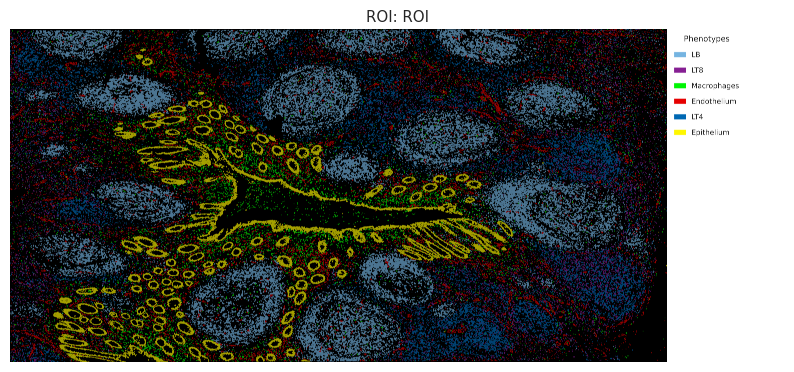

In [ ]:

for roi in np.unique(df_pheno["ROI"]):
    final_img = draw_cells_for_roi(
    df_roi=df_pheno[df_pheno["ROI"] == roi],
    roi=roi,
    path_img=path_img_raw,
    path_mask=path_mask_cell,
    custom_colors=dico_color,
    output_dir=path_img_pheno,
)


### 📊 **Heatmap of Phenotype**
*This cell creates a heatmap showing the expression of different markers within phenotypes.*


#### 🛠️ Functions

In [ ]:
def heatmap_histo(df, name_value, title, path, threshold, vmin, vmax):

    sns.set(font_scale=1)

    # --- Data ---
    data = df.groupby(name_value).mean()
    counts = df[name_value].value_counts().sort_index()

    linkage_result = linkage(data, method="ward")
    order = leaves_list(linkage_result)
    data = data.iloc[order]
    counts = counts.iloc[order]

    n_clusters = len(data)
    fig = plt.figure(figsize=(10, max(6, n_clusters * 0.4)))
    fig.patch.set_facecolor('white')
    gs = GridSpec(nrows=1, ncols=2, width_ratios=[1.2, 5], wspace=0.02)

    # --- Histogram ---
    ax_bar = fig.add_subplot(gs[0])
    y_positions = [i + 0.5 for i in range(n_clusters)]

    bars = ax_bar.barh(
        y=y_positions,
        width=counts.values,
        height=1,
        color='gray'
    )

    # Add cell counts inside the histogram
    for y, count in zip(y_positions, counts.values):
        ax_bar.text(
            count - 1,
            y,
            str(count),
            va='center',
            ha='right',
            fontsize=8
        )

    ax_bar.set_yticks([])
    ax_bar.invert_xaxis()
    ax_bar.set_xlabel("")
    ax_bar.set_xticks([])
    ax_bar.xaxis.set_label_position('top')
    ax_bar.set_facecolor('none')
    ax_bar.yaxis.set_ticks_position('none')

    for spine in ['top', 'right', 'bottom']:
        ax_bar.spines[spine].set_visible(False)

    # --- Heatmap (without colorbar) ---
    ax_heatmap = fig.add_subplot(gs[1])
    heatmap = sns.heatmap(
        data,
        ax=ax_heatmap,
        vmin=vmin,
        vmax=vmax,
        cmap="vlag",
        linewidths=0.5,
        linecolor='gray',
        xticklabels=True,
        yticklabels=False,
        cbar=False   # cbar created separately
    )

    # Y-axis ticks on the right side
    ax_heatmap.set_yticks([i + 0.5 for i in range(n_clusters)])
    ax_heatmap.set_yticklabels(data.index, fontsize=12)
    ax_heatmap.yaxis.tick_right()
    ax_heatmap.yaxis.set_label_position("right")

    # Align histogram and heatmap vertically
    ax_bar.set_ylim(ax_heatmap.get_ylim())

    # --- Red box highlighting values above threshold ---
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            value = data.iloc[i, j]
            if value > threshold:
                rect = Rectangle((j, i), 1, 1, linewidth=2,
                                 edgecolor='red', facecolor='none')
                ax_heatmap.add_patch(rect)

    # --- Main title ---
    fig.suptitle(title, fontsize=16, y=1.05)

    # --- Colorbar placed above the heatmap ---
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    import matplotlib.cm as cm

    norm = plt.Normalize(vmin=data.values.min(), vmax=data.values.max())
    sm = plt.cm.ScalarMappable(cmap="vlag", norm=norm)
    sm.set_array([])

    # Custom position: [left, bottom, width, height]
    cax = fig.add_axes([0.13, 0.94, 0.3, 0.015])
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
    cbar.ax.tick_params(labelsize=8)

    # --- Save ---
    plt.tight_layout(rect=[0, 0, 1, 0.93])  # leave space for title and colorbar
    plt.savefig(path + f"Heatmap_{name_value}.png", bbox_inches='tight')
    plt.show()


#### ⚙️ Execution

In [ ]:
df_pheno = pd.read_csv(path_main_clust + "mfi_pheno.csv")
df_pheno = df_pheno.drop(["Cell_ID", "area", "centroid-0", "centroid-1", "ROI", "label","Unnamed: 0","cluster"], axis=1)

heatmap_histo(df_pheno,"phenotype","Expression of markers according to the phenotype",path_main_clust,threshold=0.5,vmin=0,vmax=3)


### 📊 **Reduction of dimension on the cell with a defined phenotype**
*This cell performs dimensionality reduction on the Mfi of cells with a phenotype in order to visualize their consistency*

#### ⚙️ Functions

In [ ]:
%pip install pacmap
import pacmap

In [ ]:
def choose_colors_interactive(df_pheno, default_palette="tab10"):
    phenotypes = sorted(df_pheno["phenotype"].unique())
    pickers = {}
    dico_color = {}

    print("🎨 Choose a color for each phenotype:")

    for pheno in phenotypes:
        picker = widgets.ColorPicker(
            description=pheno,
            value="#1f77b4",  # couleur initiale (bleu matplotlib)
            layout=widgets.Layout(width="300px")
        )
        pickers[pheno] = picker
        display(picker)

    confirm = widgets.Button(description="✅ Confirm colors")

    def on_confirm(b):
        for ph, picker in pickers.items():
            dico_color[ph] = picker.value
        print("✔ Colors selected:")
        for k, v in dico_color.items():
            print(f"{k}: {v}")

    confirm.on_click(on_confirm)
    display(confirm)

    return dico_color


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import to_rgb

def plot_pacmap(
    df_pacmap,
    feature,
    figsize=(8, 6),
    savepath=None,
    title="",
    dico_color=None,
):
    """
    Plot PaCMAP colored by phenotype with optional user-defined colors.

    Parameters
    ----------
    df_pacmap : pd.DataFrame
        DataFrame containing PaCMAP coordinates ('0','1') and phenotype column
    feature : str
        Column name used for coloring (e.g. 'phenotype')
    dico_color : dict or None
        Mapping {phenotype: color}, where color can be hex, RGB tuple, or CSS name
    """

    # Order phenotypes by frequency (nicer legend)
    pheno_counts = df_pacmap[feature].value_counts()
    phenotypes = pheno_counts.index.tolist()

    # Base palette (fallback)
    fallback_palette = sns.color_palette("tab20", n_colors=len(phenotypes))

    pheno_to_color = {}

    for i, ph in enumerate(phenotypes):
        if dico_color is not None and ph in dico_color:
            try:
                # Convert hex / name / rgb -> RGB tuple
                pheno_to_color[ph] = to_rgb(dico_color[ph])
            except ValueError:
                raise ValueError(f"❌ Invalid color for phenotype '{ph}': {dico_color[ph]}")
        else:
            pheno_to_color[ph] = fallback_palette[i]

    # ---------------- Plot ----------------
    plt.figure(figsize=figsize)
    ax = plt.gca()

    for ph in phenotypes:
        sub = df_pacmap[df_pacmap[feature] == ph]
        ax.scatter(
            sub["0"],
            sub["1"],
            s=5,
            color=pheno_to_color[ph],
            alpha=0.7,
            edgecolor="none",
            label=f"{ph} (n={len(sub)})",
        )

    ax.set_xlabel("PaCMAP 1", fontsize=11)
    ax.set_ylabel("PaCMAP 2", fontsize=11)
    ax.set_title(title, fontsize=13, pad=10)

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0.0,
        fontsize=9,
        markerscale=4.0,
        title=feature,
    )

    sns.despine(ax=ax)
    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
        print(f"✅ The graph can be found there: {savepath}")

    plt.show()


In [ ]:
def display_reduction_marker(reduced_vector,marker,size_picture,path,title,subtitle,min,max):

  plt.figure(figsize=size_picture)
  plt.title(title+subtitle,fontsize=40)
  plt.scatter(reduced_vector[:,0],reduced_vector[:,1],c=marker,s=0.5,label=subtitle,vmin=min,vmax=max)
  plt.axis('off')
  plt.colorbar(label=subtitle)
  plt.legend(fontsize=20)
  plt.savefig(path+title+"_"+subtitle+".png")
  print("✅ The graph can be found there:  "+path+title+"_"+subtitle+".png")
  plt.show()

#### 🛠️ Execution

In [ ]:
path_reduction_dimension=path_main_clust+"reduction_dimension/"
if os.path.isdir(path_reduction_dimension)==False:
  os.mkdir(path_reduction_dimension)

In [ ]:
if os.path.isdir(path_main_clust+"reduction_dimension/markers/")==False:
  os.mkdir(path_main_clust+"reduction_dimension/markers/")

In [ ]:
df_pheno=pd.read_csv(path_main_clust+"mfi_pheno.csv")
df_pheno=df_pheno.drop(["Unnamed: 0","ROI","area","centroid-0","centroid-1","label","Cell_ID","cluster"],axis=1)

# Dynamically get the list of all marker columns from the cleaned df_pheno
all_marker_columns = df_pheno.columns.drop("phenotype").tolist()

df_umap=df_pheno.copy()
# Use the correct list of all marker columns for dimensionality reduction
df_umap=df_umap[all_marker_columns]
df_umap["phenotype"]=df_pheno["phenotype"]
df_umap=df_umap.loc[df_umap.loc[:,"phenotype"]!="No"]
print(df_umap.shape)
list_pheno=list(df_umap["phenotype"])
df_pacmap=df_umap.drop(["phenotype"],axis=1)

embedding = pacmap.PaCMAP(n_components=2, n_neighbors=None, MN_ratio=0.5, FP_ratio=2.0)
X_transformed = embedding.fit_transform(df_pacmap, init="pca")

df_pacmap=pd.DataFrame(X_transformed,columns=["0","1"])
df_pacmap["phenotype"]=list_pheno
df_pacmap.to_csv(path_clust+"pacmap_reduction_pheno.csv")
print(df_pacmap.shape)
df_pacmap.head()

In [ ]:
dico_color = choose_colors_interactive(df_pacmap)

In [ ]:
plot_pacmap(df_pacmap, "phenotype",savepath=path_reduction_dimension + "pacmap_phenotype.png",title="Main phenotypes",dico_color=dico_color)

In [ ]:
df_mfi=df_pheno.copy()
df_mfi=df_mfi[df_mfi["phenotype"]!="No"]
df_mfi=df_mfi.drop(["phenotype"],axis=1)
pacmap_embeded=np.array(df_pacmap)
for marker in df_mfi.columns:
 list_marker=list(df_mfi[marker])
 display_reduction_marker(pacmap_embeded,list_marker,(17,13),path_main_clust+"reduction_dimension/markers/","PacMap_",marker,0,5)

### 📊 **Dotplot co expression phenotypes**
⚠️ USER INPUT REQUIRED  
*Creating a graph showing the expression of markers in pairs across all phenotypes*


#### ⚙️ Functions

In [ ]:
def plot_density_df(df, marker_x, marker_y, path_out,pheno,
                    palette='tab10',
                    x_thresh=None, y_thresh=None
                    ):

    plt.figure(figsize=(8, 6))
    x = df[marker_x].values
    y = df[marker_y].values

    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)

    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]

    sc = plt.scatter(x, y, c=z, cmap='viridis', s=3, edgecolor='none', alpha=0.7)

    sns.kdeplot(x=x, y=y, levels=5, linewidths=1, color='black', alpha=0.6)

    if x_thresh is not None:
        plt.axvline(x=x_thresh, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    if y_thresh is not None:
        plt.axhline(y=y_thresh, color='red', linestyle='--', linewidth=1.5, alpha=0.8)

    if x_thresh is not None and y_thresh is not None:
        x_pos = x > x_thresh
        y_pos = y > y_thresh

        n_total = len(x)
        n_xpos = np.sum(x_pos)
        n_ypos = np.sum(y_pos)
        n_double_pos = np.sum(x_pos & y_pos)
        n_double_neg = np.sum(~x_pos & ~y_pos)

        p_xpos = 100 * n_xpos / n_total
        p_ypos = 100 * n_ypos / n_total
        p_double_pos = 100 * n_double_pos / n_total
        p_double_neg = 100 * n_double_neg / n_total

        txt = (
            f"Total cells: {n_total}\n"
            f"{marker_x}+ : {n_xpos} ({p_xpos:.1f}%)\n"
            f"{marker_y}+ : {n_ypos} ({p_ypos:.1f}%)\n"
            f"Double + : {n_double_pos} ({p_double_pos:.1f}%)\n"
            f"Double - : {n_double_neg} ({p_double_neg:.1f}%)"
        )

        plt.text(0.98, 0.98, txt, transform=plt.gca().transAxes,
                 fontsize=9, color='white', fontweight='bold',
                 ha='right', va='top',
                 bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.4'))

    plt.xlabel(marker_x)
    plt.ylabel(marker_y)
    plt.title(f"{marker_x} vs {marker_y} in {pheno}")
    plt.colorbar(sc, label='Density')

    plt.tight_layout()
    plt.savefig(path_out + f"/{marker_x}_{marker_y}.png", dpi=300)
    print(f"✅ The graph can be found there:  {path_out}")
    plt.show()


#### 🛠️ Execution

In [ ]:

df_pheno=pd.read_csv(path_main_clust+"/mfi_pheno.csv")
df_pheno=df_pheno.drop(["Cell_ID","area","centroid-0","centroid-1","ROI","label","Unnamed: 0","cluster"],axis=1)
print(df_pacmap.shape)
df_pheno.head()

In [ ]:
path_coexpression_pheno=path_main_clust+"coexpression_phenotypes/"
if os.path.isdir(path_coexpression_pheno)==False:
  os.mkdir(path_coexpression_pheno)

##### Choose the markers

In [ ]:
dico_pheno_marker={}
for p in np.unique(df_pheno["phenotype"]):
  list_marker=input("Enter the markers you want to display for the phenotype "+p+": ")
  list_marker=list_marker.split(",")
  dico_pheno_marker[p]=list_marker

In [ ]:
threshold=float(input("Enter the threshold for the density plot: "))


In [ ]:
for pheno in dico_pheno_marker.keys():
  print(pheno)
  df_sub=df_pheno[df_pheno["phenotype"]==pheno]
  if os.path.isdir(path_coexpression_pheno+str(pheno))==False:
    os.mkdir(path_coexpression_pheno+str(pheno))
  for m in range(len(dico_pheno_marker[pheno])):
    marker=list(dico_pheno_marker[pheno])[m]
    if marker!="phenotype":
      for m2 in range(m+1,len(dico_pheno_marker[pheno])):
        marker2=list(dico_pheno_marker[pheno])[m2]
        if marker2!="phenotype" and marker2!=marker:
          plot_density_df(df_sub,marker,marker2,path_coexpression_pheno+str(pheno),pheno,x_thresh=threshold,y_thresh=threshold)

##### Co-expression of all the markers

In [ ]:
threshold=float(input("Enter the threshold for the density plot: "))

In [ ]:
for pheno in np.unique(df_pheno["phenotype"]):
 if pheno!="No":
  print(pheno)
  df=df_pheno[df_pheno["phenotype"]==pheno]
  if os.path.isdir(path_coexpression_pheno+str(pheno))==False:
    os.mkdir(path_coexpression_pheno+str(pheno))
  for m in range(len(list(df.columns))):
    marker=list(df.columns)[m]
    if marker!="phenotype":
      for m2 in range(m+1,len(list(df.columns))):
        marker2=list(df.columns)[m2]
        if marker2!="phenotype" and marker2!=marker:
          plot_density_df(df,marker,marker2,path_coexpression_pheno+str(pheno),pheno,x_thresh=threshold,y_thresh=threshold)

### 📊 **Outline the phenotypes**
⚠️ USER INPUT REQUIRED  
*To assess the quality of the phenotype annotation, this cell creates images for each phenotype, including the appropriate markers and an image with the outlines of the cells belonging to that phenotype.*

#### 🛠️ Functions

In [ ]:
import os
import numpy as np
import cv2
from PIL import Image
from tqdm.auto import tqdm
from skimage.segmentation import find_boundaries

# ---------- IO ----------
def read_gray(path):
    arr = np.array(Image.open(path))
    if arr.ndim > 2:
        arr = arr[..., 0]
    return arr.astype(np.float32)

# ---------- Normalisation robuste (anti-voile gris) ----------
def normalize_robust_uint8(arr, p_low=1.0, p_high=99.8, gamma=1.0):
    """
    Clip percentiles + rescale 0..255 + gamma.
    Très supérieur au min-max sur grandes images.
    """
    if arr is None:
        return None
    lo, hi = np.percentile(arr, [p_low, p_high])
    if hi <= lo:
        out = np.zeros_like(arr, dtype=np.uint8)
        return out

    x = np.clip(arr, lo, hi)
    x = (x - lo) / (hi - lo)

    if gamma != 1.0:
        x = np.power(x, gamma)

    return (x * 255).astype(np.uint8)

# ---------- Marqueurs : sum / mean / max ----------
def load_and_combine_markers(roi, markers, path_img_raw, combine="max"):
    imgs = []
    for m in markers:
        # essaye tif/tiff/png
        for ext in (".tif", ".tiff", ".png", ".jpg", ".jpeg"):
            p = os.path.join(path_img_raw, roi, f"{m}{ext}")
            if os.path.isfile(p):
                imgs.append(read_gray(p))
                break

    if not imgs:
        return None

    stack = np.stack(imgs, axis=0)

    if combine == "sum":
        out = np.sum(stack, axis=0)
    elif combine == "mean":
        out = np.mean(stack, axis=0)
    elif combine == "max":
        out = np.max(stack, axis=0)
    else:
        raise ValueError("combine must be one of: 'sum', 'mean', 'max'")

    # Option : arcsinh, mais moins agressif que *10
    out = np.arcsinh(out * 3.0)

    return out

# ---------- Contours complets pour un sous-ensemble de labels ----------
def boundaries_for_labels(mask, labels, mode="outer", thickness=2):
    """
    Important: on met à 0 les labels non sélectionnés,
    puis find_boundaries sur ce label-image => contours complets.
    """
    labels = np.asarray(list(labels), dtype=np.int64)
    sel = np.isin(mask, labels)

    # label image "restreinte" : conserve les IDs pour les cellules sélectionnées, sinon 0
    mask_sel = np.where(sel, mask, 0).astype(np.int64)

    # frontières complètes (outer donne des contours plus "fermés")
    b = find_boundaries(mask_sel, mode=mode)  # bool

    if thickness > 1:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*thickness+1, 2*thickness+1))
        b = cv2.dilate((b.astype(np.uint8) * 255), k) > 0

    return b

# ---------- Pipeline ROI x phenotype ----------
def generate_pheno_outline_images(
    df_pheno,
    dico_pheno_marker,
    path_img_raw,
    path_mask,
    output_dir,
    contour_colors=None,         # dict pheno -> (R,G,B) optionnel
    default_contour_color=(255, 255, 0),
    contour_thickness=2,
    combine_markers="max",       # 'max' recommandé pour éviter surexposition
    p_low=1.0,
    p_high=99.8,
    gamma=0.9,
    boundary_mode="outer"
):
    os.makedirs(output_dir, exist_ok=True)

    rois = df_pheno["ROI"].unique()

    for roi in tqdm(rois, desc="ROIs"):
        # masque
        mask_path = None
        for ext in (".tif", ".tiff", ".png"):
            p = os.path.join(path_mask, f"{roi}{ext}")
            if os.path.isfile(p):
                mask_path = p
                break
        if mask_path is None:
            continue

        mask = np.array(Image.open(mask_path))
        if mask.ndim > 2:
            mask = mask[..., 0]
        mask = mask.astype(np.int64)

        df_roi = df_pheno[df_pheno["ROI"] == roi]

        for pheno, markers in dico_pheno_marker.items():
            df_p = df_roi[df_roi["phenotype"] == pheno]
            if df_p.empty:
                continue

            # image marqueurs (max/sum/mean)
            img = load_and_combine_markers(roi, markers, path_img_raw, combine=combine_markers)
            if img is None:
                continue

            # normalisation robuste -> supprime le voile gris
            img8 = normalize_robust_uint8(img, p_low=p_low, p_high=p_high, gamma=gamma)
            img_rgb = np.dstack([img8]*3)

            # labels du phénotype
            labels = set(df_p["label"].astype(int).values)

            # contours complets (corrige votre problème)
            b = boundaries_for_labels(mask, labels, mode=boundary_mode, thickness=contour_thickness)

            # couleur contour
            if contour_colors and pheno in contour_colors:
                color = contour_colors[pheno]
            else:
                color = default_contour_color

            img_rgb[b] = color

            # save
            out_dir = os.path.join(output_dir, pheno)
            os.makedirs(out_dir, exist_ok=True)
            out_path = os.path.join(out_dir, f"{roi}.png")
            Image.fromarray(img_rgb).save(out_path)

    print(f"✅ Images générées dans: {output_dir}")


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def build_dico_pheno_marker_interactive(list_pheno, list_marker, title="Phenotype → marker selection"):
    # Nettoyage
    list_pheno = [p.strip() for p in list_pheno if str(p).strip()]
    list_marker = [m.strip() for m in list_marker if str(m).strip()]

    state = {"i": 0, "dico": {}}

    pheno_lbl = widgets.HTML()
    marker_sel = widgets.SelectMultiple(
        options=list_marker,
        description="Markers",
        rows=min(12, len(list_marker)),
        layout=widgets.Layout(width="460px", height="220px")
    )

    btn_save_next = widgets.Button(description="✅ Save & Next", button_style="success")
    btn_skip = widgets.Button(description="⏭ Skip", button_style="")
    btn_finish = widgets.Button(description="🏁 Finish", button_style="info")

    out = widgets.Output()

    def render():
        clear_output(wait=True)

        if state["i"] >= len(list_pheno):
            display(widgets.HTML("<h3 style='color:#2ca02c'>✔ Selection finished</h3>"))
            display(out)
            with out:
                out.clear_output(wait=True)
                print("dico_pheno_marker =")
                print(state["dico"])
            return

        ph = list_pheno[state["i"]]
        pheno_lbl.value = f"<h3 style='color:#1976d2'>🧬 Phenotype: {ph}</h3>"

        # pré-remplir si déjà défini
        marker_sel.value = tuple(state["dico"].get(ph, []))

        display(widgets.HTML(f"<h2 style='color:#1976d2'>{title}</h2>"))
        display(pheno_lbl)
        display(widgets.HTML("<b>Select the markers associated with this phenotype:</b>"))
        display(marker_sel)
        display(widgets.HBox([btn_save_next, btn_skip, btn_finish]))
        display(out)

        with out:
            out.clear_output(wait=True)
            done = sum(1 for p in list_pheno if p in state["dico"])
            print(f"Progress: {done}/{len(list_pheno)} phenotypes completed.")

    def on_save_next(_):
        ph = list_pheno[state["i"]]
        state["dico"][ph] = list(marker_sel.value)
        state["i"] += 1
        render()

    def on_skip(_):
        ph = list_pheno[state["i"]]
        state["dico"][ph] = []
        state["i"] += 1
        render()

    def on_finish(_):
        # sauvegarde le phénotype en cours avant de terminer
        if state["i"] < len(list_pheno):
            ph = list_pheno[state["i"]]
            state["dico"][ph] = list(marker_sel.value)
        state["i"] = len(list_pheno)
        render()

    btn_save_next.on_click(on_save_next)
    btn_skip.on_click(on_skip)
    btn_finish.on_click(on_finish)

    render()
    return state  # state["dico"] contient le dictionnaire final


#### ⚙️ Execution

In [ ]:
df_pheno = pd.read_csv(path_main_clust + "mfi_pheno.csv")
df_num=df_pheno.drop(["Cell_ID","area","centroid-0","centroid-1","ROI","label","cluster","phenotype","Unnamed: 0"],axis=1)

df_num.head()

In [ ]:
# Exemples
list_pheno = np.unique(df_pheno["phenotype"])
list_marker = np.unique(df_num.columns)

state = build_dico_pheno_marker_interactive(list_pheno, list_marker)

# Après sélection (et Finish), récupérez :
dico_pheno_marker = state["dico"]


In [ ]:
path_check_pheno=path_main_clust+"check_pheno_outline/"
if os.path.isdir(path_check_pheno)==False:
  os.mkdir(path_check_pheno)
path_processing=path+"images/img_processing_1/Biopsies/"

In [ ]:
generate_pheno_outline_images(
    df_pheno=df_pheno,
    dico_pheno_marker=dico_pheno_marker,
    path_img_raw=path_img_raw,
    path_mask=path_mask_cell,
    output_dir=path_check_pheno,
    combine_markers="max",
    p_low=5.0, p_high=99.8, gamma=0.9,
    contour_thickness=1,
    boundary_mode="outer"
)


### 📊 **Visualization of the ouline of the objects belonging to a phenotype on images withthe appropriate markers from biopsies samples**
⚠️ USER INPUT REQUIRED  
*To assess the quality of phenotype annotation, this cell creates images for each phenotype, including the appropriate markers and an image with the outlines of the cells belonging to that phenotype, on biopsy samples whose size and number can be chosen.*

#### Function

In [ ]:
# ======================================================
# ROI x phenotype: create N random (or informative) samples
# Left  : markers-only patch
# Right : same patch + complete cell contours for selected phenotype labels
# + a small spacer between left/right for readability
# ======================================================

import os
import numpy as np
import cv2
from PIL import Image
from tqdm.auto import tqdm
from skimage.segmentation import find_boundaries

# -----------------------------
# I/O
# -----------------------------
SUPPORTED_IMG_EXT = (".tif", ".tiff", ".png", ".jpg", ".jpeg")
SUPPORTED_MASK_EXT = (".tif", ".tiff", ".png")

def read_gray(path):
    """Read image as float32 grayscale."""
    arr = np.array(Image.open(path))
    if arr.ndim > 2:
        arr = arr[..., 0]
    return arr.astype(np.float32)

def find_first_existing(path_no_ext):
    """Try supported extensions for a path without extension and return the first existing path, else None."""
    for ext in SUPPORTED_IMG_EXT:
        p = path_no_ext + ext
        if os.path.isfile(p):
            return p
    return None

def find_mask_path(path_mask, roi):
    """Find ROI mask file in path_mask with supported extensions."""
    for ext in SUPPORTED_MASK_EXT:
        p = os.path.join(path_mask, f"{roi}{ext}")
        if os.path.isfile(p):
            return p
    return None

# -----------------------------
# Robust normalization (anti gray veil)
# -----------------------------
def normalize_robust_uint8(arr, p_low=1.0, p_high=99.8, gamma=1.0, eps=1e-8):
    """
    Percentile clip + rescale to uint8 + gamma correction.
    Works well on large biopsies (prevents "gray haze").
    """
    if arr is None:
        return None
    lo, hi = np.percentile(arr, [p_low, p_high])
    if hi <= lo + eps:
        return np.zeros_like(arr, dtype=np.uint8)

    x = np.clip(arr, lo, hi)
    x = (x - lo) / (hi - lo)

    if gamma != 1.0:
        x = np.power(x, gamma)

    return (x * 255).astype(np.uint8)

# -----------------------------
# Marker combine (sum/mean/max)
# -----------------------------
def load_and_combine_markers(roi, markers, path_img_raw, combine="max", arcsinh_scale=3.0):
    """
    Load several marker images for a ROI and combine them into one grayscale image.
    combine: 'max' (recommended), 'mean', or 'sum'
    arcsinh_scale: scaling inside arcsinh to control contrast.
    """
    imgs = []
    for m in markers:
        p = find_first_existing(os.path.join(path_img_raw, roi, m))
        if p is None:
            continue
        imgs.append(read_gray(p))

    if not imgs:
        return None

    stack = np.stack(imgs, axis=0)

    if combine == "sum":
        out = np.sum(stack, axis=0)
    elif combine == "mean":
        out = np.mean(stack, axis=0)
    elif combine == "max":
        out = np.max(stack, axis=0)
    else:
        raise ValueError("combine must be one of: 'sum', 'mean', 'max'")

    # Gentle transform to reduce outlier dominance
    out = np.arcsinh(out * float(arcsinh_scale))
    return out

# -----------------------------
# Complete boundaries for subset of labels
# -----------------------------
def boundaries_for_labels(mask, labels, mode="outer", thickness=2):
    """
    Keep only selected labels in the mask, then compute boundaries => complete contours.
    mode: 'outer' recommended for closed-ish boundaries.
    thickness: dilation thickness (>=1)
    """
    labels = np.asarray(list(labels), dtype=np.int64)
    if labels.size == 0:
        return np.zeros(mask.shape, dtype=bool)

    sel = np.isin(mask, labels)
    mask_sel = np.where(sel, mask, 0).astype(np.int64)

    b = find_boundaries(mask_sel, mode=mode)  # bool

    if thickness > 1:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * thickness + 1, 2 * thickness + 1))
        b = cv2.dilate((b.astype(np.uint8) * 255), k) > 0

    return b

# -----------------------------
# Patch sampling
# -----------------------------
def sample_patch_coords(H, W, patch_size, n_samples, rng):
    """
    Returns list of (y0, y1, x0, x1) boxes within bounds.
    """
    ps = int(patch_size)
    if ps <= 0:
        raise ValueError("patch_size must be > 0")

    if ps > H or ps > W:
        ps = min(H, W)

    coords = []
    for _ in range(n_samples):
        y0 = int(rng.integers(0, max(1, H - ps + 1)))
        x0 = int(rng.integers(0, max(1, W - ps + 1)))
        coords.append((y0, y0 + ps, x0, x0 + ps))
    return coords

# -----------------------------
# Main pipeline
# -----------------------------
def generate_pheno_outline_samples_side_by_side(
    df_pheno,
    dico_pheno_marker,
    path_img_raw,
    path_mask,
    output_dir,
    n_samples=5,
    patch_size=512,
    seed=0,
    contour_colors=None,          # dict pheno -> (R,G,B) optional
    default_contour_color=(255, 255, 0),
    contour_thickness=2,
    combine_markers="max",
    arcsinh_scale=3.0,
    p_low=1.0,
    p_high=99.8,
    gamma=0.9,
    boundary_mode="outer",
    only_informative=True,        # try to pick patches containing contours
    min_boundary_pixels=50,
    spacer_width=20,              # space between left/right
    spacer_color=255              # 255=white, 0=black
):
    """
    Creates for each ROI and phenotype:
      - N patch samples
      - side-by-side image: left markers-only, right markers+contours
      - adds a spacer between the two images
    Output structure:
      output_dir/<phenotype>/<ROI>__sampleK_yY_xX.png
    """
    os.makedirs(output_dir, exist_ok=True)
    rng = np.random.default_rng(seed)

    # safety checks
    required_cols = {"ROI", "phenotype", "label"}
    missing_cols = required_cols - set(df_pheno.columns)
    if missing_cols:
        raise ValueError(f"df_pheno missing required columns: {missing_cols}")

    rois = df_pheno["ROI"].dropna().unique()

    for roi in tqdm(rois, desc="ROIs"):
        mask_path_roi = find_mask_path(path_mask, roi)
        if mask_path_roi is None:
            continue

        # Load mask
        mask = np.array(Image.open(mask_path_roi))
        if mask.ndim > 2:
            mask = mask[..., 0]
        mask = mask.astype(np.int64)
        H, W = mask.shape[:2]

        df_roi = df_pheno[df_pheno["ROI"] == roi]

        for pheno, markers in dico_pheno_marker.items():
            df_p = df_roi[df_roi["phenotype"] == pheno]
            if df_p.empty:
                continue

            labels = set(df_p["label"].astype(int).values)
            if len(labels) == 0:
                continue

            # Load & combine markers once for this (ROI, phenotype)
            img_full = load_and_combine_markers(
                roi=roi,
                markers=markers,
                path_img_raw=path_img_raw,
                combine=combine_markers,
                arcsinh_scale=arcsinh_scale
            )
            if img_full is None:
                continue

            # Robust normalization to uint8
            img8_full = normalize_robust_uint8(img_full, p_low=p_low, p_high=p_high, gamma=gamma)
            img_rgb_full = np.dstack([img8_full] * 3).astype(np.uint8)

            # Compute boundaries once
            b_full = boundaries_for_labels(mask, labels, mode=boundary_mode, thickness=contour_thickness)

            # Choose contour color
            if contour_colors and pheno in contour_colors:
                color = contour_colors[pheno]
            else:
                color = default_contour_color

            # Sample patches
            if only_informative:
                coords = []
                candidates = sample_patch_coords(H, W, patch_size, n_samples * 10, rng)
                for (y0, y1, x0, x1) in candidates:
                    if int(b_full[y0:y1, x0:x1].sum()) >= int(min_boundary_pixels):
                        coords.append((y0, y1, x0, x1))
                    if len(coords) >= n_samples:
                        break
                if len(coords) < n_samples:
                    coords += sample_patch_coords(H, W, patch_size, n_samples - len(coords), rng)
            else:
                coords = sample_patch_coords(H, W, patch_size, n_samples, rng)

            # Output folder per phenotype
            out_dir_ph = os.path.join(output_dir, pheno)
            os.makedirs(out_dir_ph, exist_ok=True)

            for k, (y0, y1, x0, x1) in enumerate(coords, start=1):
                left = img_rgb_full[y0:y1, x0:x1].copy()

                right = left.copy()
                b_patch = b_full[y0:y1, x0:x1]
                right[b_patch] = color

                # spacer between left and right
                spacer = np.full((left.shape[0], int(spacer_width), 3), int(spacer_color), dtype=np.uint8)

                # side-by-side with spacer
                side = np.concatenate([left, spacer, right], axis=1)

                out_path = os.path.join(out_dir_ph, f"{roi}__sample{k}_y{y0}_x{x0}.png")
                Image.fromarray(side).save(out_path)

    print(f"✅ Samples generated in: {output_dir}")


# ======================================================
# Example usage:
# n_samples = int(input("Number of samples per ROI? (e.g., 5): "))
# patch_size = int(input("Patch size (px)? (e.g., 512 or 1024): "))
#
# generate_pheno_outline_samples_side_by_side(
#     df_pheno=df_pheno,
#     dico_pheno_marker=dico_pheno_marker,
#     path_img_raw=path_img_raw,
#     path_mask=path_mask_cell,
#     output_dir=path_output_samples,
#     n_samples=n_samples,
#     patch_size=patch_size,
#     spacer_width=25,
#     spacer_color=255
# )
# ======================================================


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def build_dico_pheno_marker_interactive(list_pheno, list_marker, title="Phenotype → marker selection"):
    # Nettoyage
    list_pheno = [p.strip() for p in list_pheno if str(p).strip()]
    list_marker = [m.strip() for m in list_marker if str(m).strip()]

    state = {"i": 0, "dico": {}}

    pheno_lbl = widgets.HTML()
    marker_sel = widgets.SelectMultiple(
        options=list_marker,
        description="Markers",
        rows=min(12, len(list_marker)),
        layout=widgets.Layout(width="460px", height="220px")
    )

    btn_save_next = widgets.Button(description="✅ Save & Next", button_style="success")
    btn_skip = widgets.Button(description="⏭ Skip", button_style="")
    btn_finish = widgets.Button(description="🏁 Finish", button_style="info")

    out = widgets.Output()

    def render():
        clear_output(wait=True)

        if state["i"] >= len(list_pheno):
            display(widgets.HTML("<h3 style='color:#2ca02c'>✔ Selection finished</h3>"))
            display(out)
            with out:
                out.clear_output(wait=True)
                print("dico_pheno_marker =")
                print(state["dico"])
            return

        ph = list_pheno[state["i"]]
        pheno_lbl.value = f"<h3 style='color:#1976d2'>🧬 Phenotype: {ph}</h3>"

        # pré-remplir si déjà défini
        marker_sel.value = tuple(state["dico"].get(ph, []))

        display(widgets.HTML(f"<h2 style='color:#1976d2'>{title}</h2>"))
        display(pheno_lbl)
        display(widgets.HTML("<b>Select the markers associated with this phenotype:</b>"))
        display(marker_sel)
        display(widgets.HBox([btn_save_next, btn_skip, btn_finish]))
        display(out)

        with out:
            out.clear_output(wait=True)
            done = sum(1 for p in list_pheno if p in state["dico"])
            print(f"Progress: {done}/{len(list_pheno)} phenotypes completed.")

    def on_save_next(_):
        ph = list_pheno[state["i"]]
        state["dico"][ph] = list(marker_sel.value)
        state["i"] += 1
        render()

    def on_skip(_):
        ph = list_pheno[state["i"]]
        state["dico"][ph] = []
        state["i"] += 1
        render()

    def on_finish(_):
        # sauvegarde le phénotype en cours avant de terminer
        if state["i"] < len(list_pheno):
            ph = list_pheno[state["i"]]
            state["dico"][ph] = list(marker_sel.value)
        state["i"] = len(list_pheno)
        render()

    btn_save_next.on_click(on_save_next)
    btn_skip.on_click(on_skip)
    btn_finish.on_click(on_finish)

    render()
    return state  # state["dico"] contient le dictionnaire final


#### Execution

In [ ]:
df_pheno = pd.read_csv(path_main_clust + "mfi_pheno.csv")
df_num=df_pheno.drop(["Cell_ID","area","centroid-0","centroid-1","ROI","label","cluster","phenotype","Unnamed: 0"],axis=1)

df_num.head()

,CD20,CD3,CD31,CD4,CD45,CD68,CD8,ECadh,HLADR,PanCK
0,0.164367,-1.108856,-0.715654,-0.960061,-0.879061,-0.651662,-0.844097,-0.571142,0.321852,-0.314348
1,1.307160,-0.951574,-0.363803,-0.818964,-0.412138,-0.593604,-0.531393,-0.275995,1.126716,-0.111590
2,0.865467,0.578926,-0.239202,-0.034866,0.192290,-0.826603,-0.501163,-0.113015,0.267491,-0.059537
3,-1.166210,-1.196931,-1.304380,-1.743309,-3.281630,-1.051724,-1.260746,-0.543914,-1.103340,-0.099867
4,-1.182756,0.306794,-1.172444,-0.041667,-0.621397,-0.463416,-0.761079,0.281710,-1.032488,-0.179020


In [ ]:
path_check_pheno=path_main_clust+"check_pheno_outline_crop/"
if os.path.isdir(path_check_pheno)==False:
  os.mkdir(path_check_pheno)
path_processing=path+"images/img_processing_1/Biopsies/"

In [ ]:
list_pheno = np.unique(df_pheno["phenotype"])
list_marker = np.unique(df_num.columns)

state = build_dico_pheno_marker_interactive(list_pheno, list_marker)
dico_pheno_marker = state["dico"]


HTML(value="<h3 style='color:#2ca02c'>✔ Selection finished</h3>")

Output()

In [ ]:
n_samples = int(input("Number of samples per biopsy ? (ex: 5) : "))
patch_size = int(input("Size of the samples (pixels) ? (ex: 512 ou 1024) : "))

generate_pheno_outline_samples_side_by_side(
    df_pheno=df_pheno,
    dico_pheno_marker=dico_pheno_marker,
    path_img_raw=path_img_raw,
    path_mask=path_mask_cell,
    output_dir=path_check_pheno,
    n_samples=n_samples,
    patch_size=patch_size,
    contour_colors=None,
    contour_thickness=1,
    combine_markers="max",
    gamma=0.9,
    only_informative=True
)


Nombre d'échantillons par biopsie (ROI) ? (ex: 5) : 5
Taille des échantillons (pixels) ? (ex: 512 ou 1024) : 1024


ROIs:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (119362188 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (119362188 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (119362188 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (119362188 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (119362188 pixels) exceeds limit of 89478485 pixels, could be decompression bomb

✅ Samples generated in: /content/gdrive/MyDrive/these/pipeline/Appendix/clustering/main_clustering/check_pheno_outline_crop/
